In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load data

In [183]:
df = pd.read_csv("screentime.csv")

In [90]:
df["MissingValue"] = df["Health_Impacts"].isnull()

In [ ]:
df["Health_Impacts"].str.get_dummies(", ")

,Anxiety,Eye Strain,Obesity Risk,Poor Sleep
0,0,1,0,1
1,0,0,0,1
2,0,0,0,1
3,0,0,0,0
4,1,0,0,1
...,...,...,...,...
9707,0,0,0,1
9708,0,0,0,1
9709,1,1,0,1
9710,0,0,0,1


In [163]:
df.loc[pd.Series(stats.zscore(df["Avg_Daily_Screen_Time_hr"]))
       .sort_values(ascending=False)
       .head(10)
       .index]

# Return 10 rows with the highest z-scores using pandas functionality
df.nsmallest(10, "Avg_Daily_Screen_Time_hr")

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,MissingValue
19,9,Female,0.0,TV,False,0.42,NaN,Urban,True
46,9,Female,0.0,Smartphone,False,0.47,NaN,Urban,True
58,9,Male,0.0,Smartphone,False,0.59,NaN,Rural,True
92,10,Female,0.0,Tablet,False,0.40,NaN,Urban,True
96,10,Male,0.0,Smartphone,False,0.45,NaN,Rural,True
145,9,Female,0.0,Tablet,False,0.49,NaN,Rural,True
287,10,Male,0.0,TV,False,0.47,NaN,Rural,True
300,8,Male,0.0,Smartphone,False,0.44,NaN,Urban,True
313,9,Male,0.0,Tablet,False,0.44,NaN,Urban,True
322,8,Female,0.0,Smartphone,False,0.55,NaN,Urban,True


In [ ]:
df["Primary_Device"].str.lower().str.capitalize().apply()

0       Smartphone
1           Laptop
2               Tv
3           Laptop
4       Smartphone
           ...    
9707    Smartphone
9708    Smartphone
9709    Smartphone
9710            Tv
9711            Tv
Name: Primary_Device, Length: 9712, dtype: object

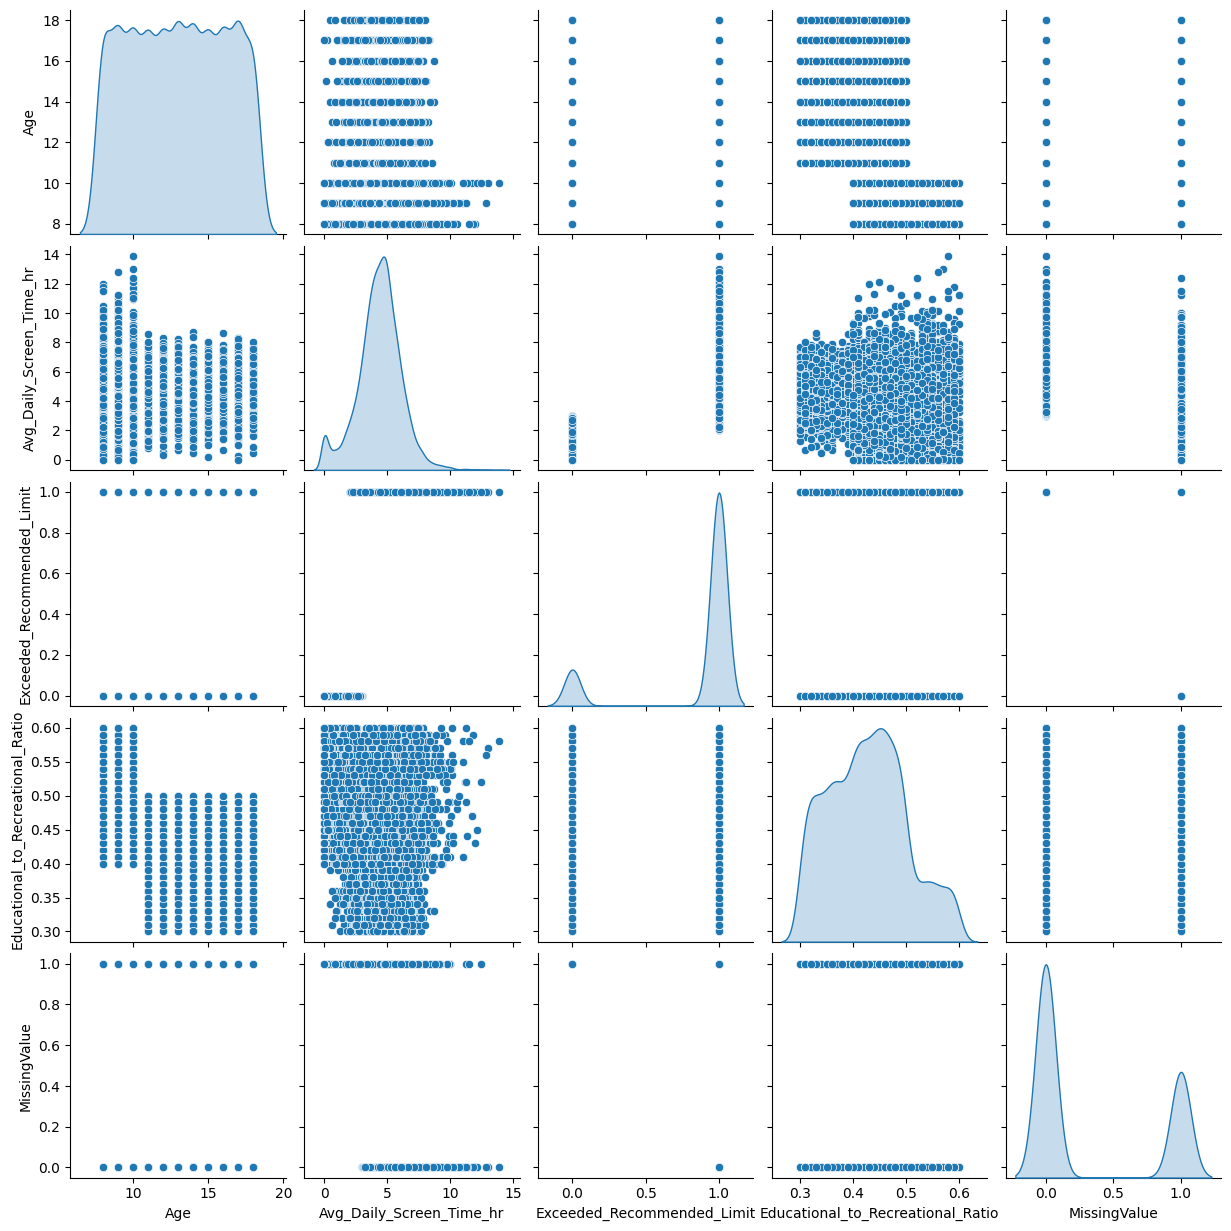

In [166]:
sns.pairplot(df, diag_kind="kde")

AttributeError: QuadMesh.set() got an unexpected keyword argument 'format'

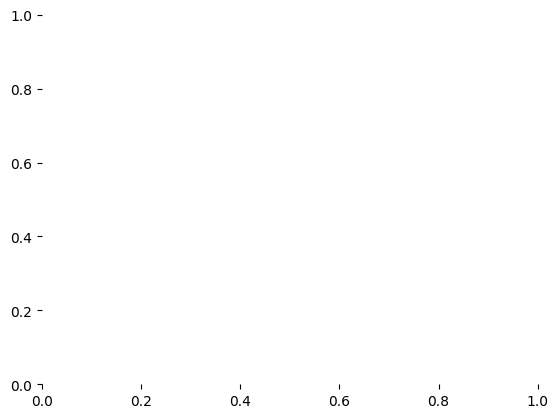

In [ ]:
# Plotting the distribution of average daily screen time
sns.heatmap(pd.get_dummies(pd.cut(df["Avg_Daily_Screen_Time_hr"], bins=10), prefix="Screen_Time_", ).corr(), annot=True, )

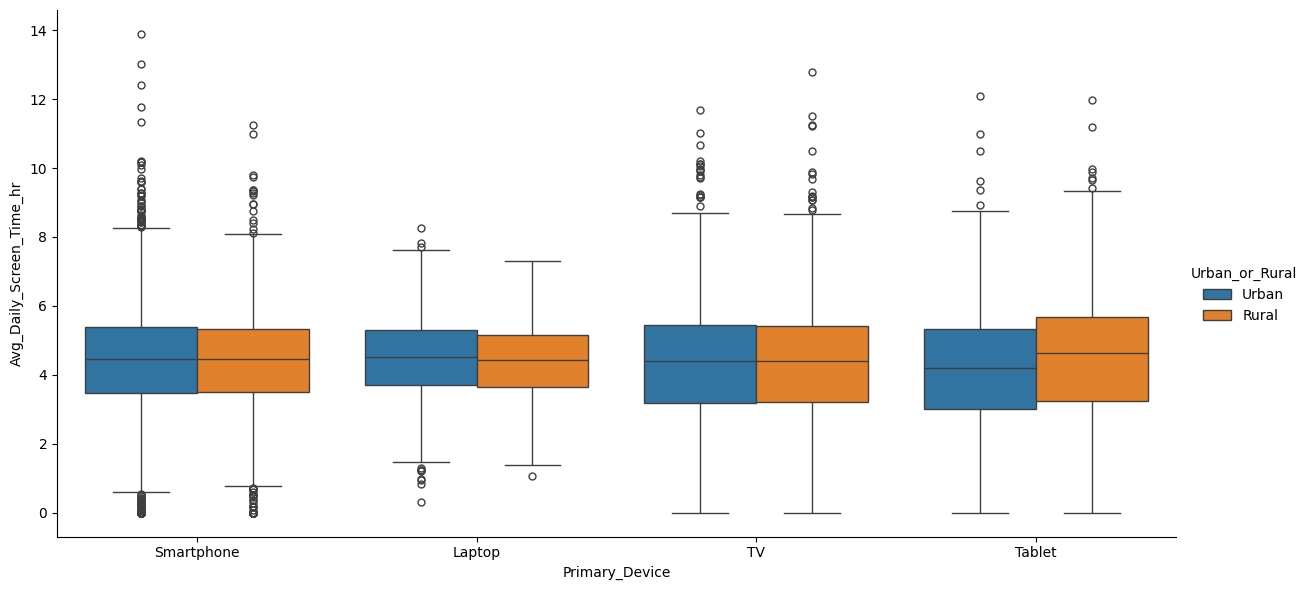

In [134]:
sns.catplot(
    data=df,
    y="Avg_Daily_Screen_Time_hr",
    x="Primary_Device",
    hue="Urban_or_Rural",
    kind="box",
    height=6,
    aspect=2,
)

In [79]:
df.sort_values(by="ScreenTime", ascending=False)

,Smartphone,TV,Tablet,Age,Gender,ScreenTime,Exceeded_Recommended_Limit,EducationalRatio,Urban_or_Rural,Anxiety,Eye Strain,Obesity Risk,Poor Sleep,Missing_Health_Impacts
4298,1,0,0,10,0,13.89,1,0.58,1,1,1,0,0,0
934,1,0,0,10,0,13.01,1,0.57,1,1,0,0,1,0
1769,0,1,0,9,1,12.80,1,0.56,0,1,1,0,0,0
1870,1,0,0,10,1,12.40,1,0.52,1,0,0,0,0,1
1321,0,0,1,10,0,12.09,1,0.45,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7828,0,1,0,9,0,0.00,0,0.55,0,0,0,0,0,1
1781,0,0,1,10,0,0.00,0,0.49,1,0,0,0,0,1
6927,1,0,0,9,0,0.00,0,0.49,1,0,0,0,0,1
2659,1,0,0,8,0,0.00,0,0.45,1,0,0,0,0,1


In [162]:
# Fill NAs with mod
df["Avg_Daily_Screen_Time_hr"] * df["MissingValue"]

0       0.00
1       0.00
2       0.00
3       1.21
4       0.00
        ... 
9707    0.00
9708    0.00
9709    0.00
9710    0.00
9711    0.00
Length: 9712, dtype: float64

# Reformat data

In [19]:
df = df.rename(columns={"Avg_Daily_Screen_Time_hr": "ScreenTime", "Educational_to_Recreational_Ratio": "EducationalRatio"})

In [20]:
# Create new binary columns from the "Health_Impacts" column
health_impacts = df["Health_Impacts"].str.get_dummies(sep=", ")
df = pd.concat([df, health_impacts], axis=1)

In [14]:
df

,Age,Gender,ScreenTime,Primary_Device,Exceeded_Recommended_Limit,EducationalRatio,Health_Impacts,Urban_or_Rural,Anxiety,Eye Strain,Obesity Risk,Poor Sleep,Anxiety,Eye Strain,Obesity Risk,Poor Sleep,Anxiety,Eye Strain,Obesity Risk,Poor Sleep
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,0,1,0,1,0,1,0,1,0,1,0,1
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,0,0,0,1,0,0,0,1,0,0,0,1
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,0,0,0,1,0,0,0,1,0,0,0,1
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,0,0,0,0,0,0,0,0,0,0,0,0
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,1,0,0,1,1,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,0,0,0,1,0,0,0,1,0,0,0,1
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,0,0,0,1,0,0,0,1,0,0,0,1
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,1,1,0,1,1,1,0,1,1,1,0,1
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,0,0,0,1,0,0,0,1,0,0,0,1


In [21]:
# Get dummies for categorical variables
df["Gender"] = pd.get_dummies(df["Gender"], drop_first=True, dtype=int)
df["Exceeded_Recommended_Limit"] = df["Exceeded_Recommended_Limit"].astype(int)
df = pd.concat([pd.get_dummies(df["Primary_Device"], drop_first=True, dtype=int), df], axis=1).drop("Primary_Device", axis=1)
df["Urban_or_Rural"] = pd.get_dummies(df["Urban_or_Rural"], drop_first=True, dtype=int)

In [ ]:
df = df.drop("Health Impacts", axis=1)

,Smartphone,TV,Tablet,Age,Gender,ScreenTime,Exceeded_Recommended_Limit,EducationalRatio,Health_Impacts,Urban_or_Rural,Anxiety,Eye Strain,Obesity Risk,Poor Sleep
0,1,0,0,14,1,3.99,1,0.42,"Poor Sleep, Eye Strain",1,0,1,0,1
1,0,0,0,11,0,4.61,1,0.30,Poor Sleep,1,0,0,0,1
2,0,1,0,18,0,3.73,1,0.32,Poor Sleep,1,0,0,0,1
3,0,0,0,15,0,1.21,0,0.39,NaN,1,0,0,0,0
4,1,0,0,12,0,5.89,1,0.49,"Poor Sleep, Anxiety",1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,1,0,0,17,1,3.26,1,0.44,Poor Sleep,1,0,0,0,1
9708,1,0,0,17,0,4.43,1,0.40,Poor Sleep,0,0,0,0,1
9709,1,0,0,16,1,5.62,1,0.39,"Poor Sleep, Eye Strain, Anxiety",0,1,1,0,1
9710,0,1,0,17,1,5.60,1,0.43,Poor Sleep,1,0,0,0,1


In [24]:
# Note that some kids have missing health impacts
df["Missing_Health_Impacts"] = df["Health_Impacts"].isna().astype(int)
df = df.drop("Health_Impacts", axis=1)

# EDA

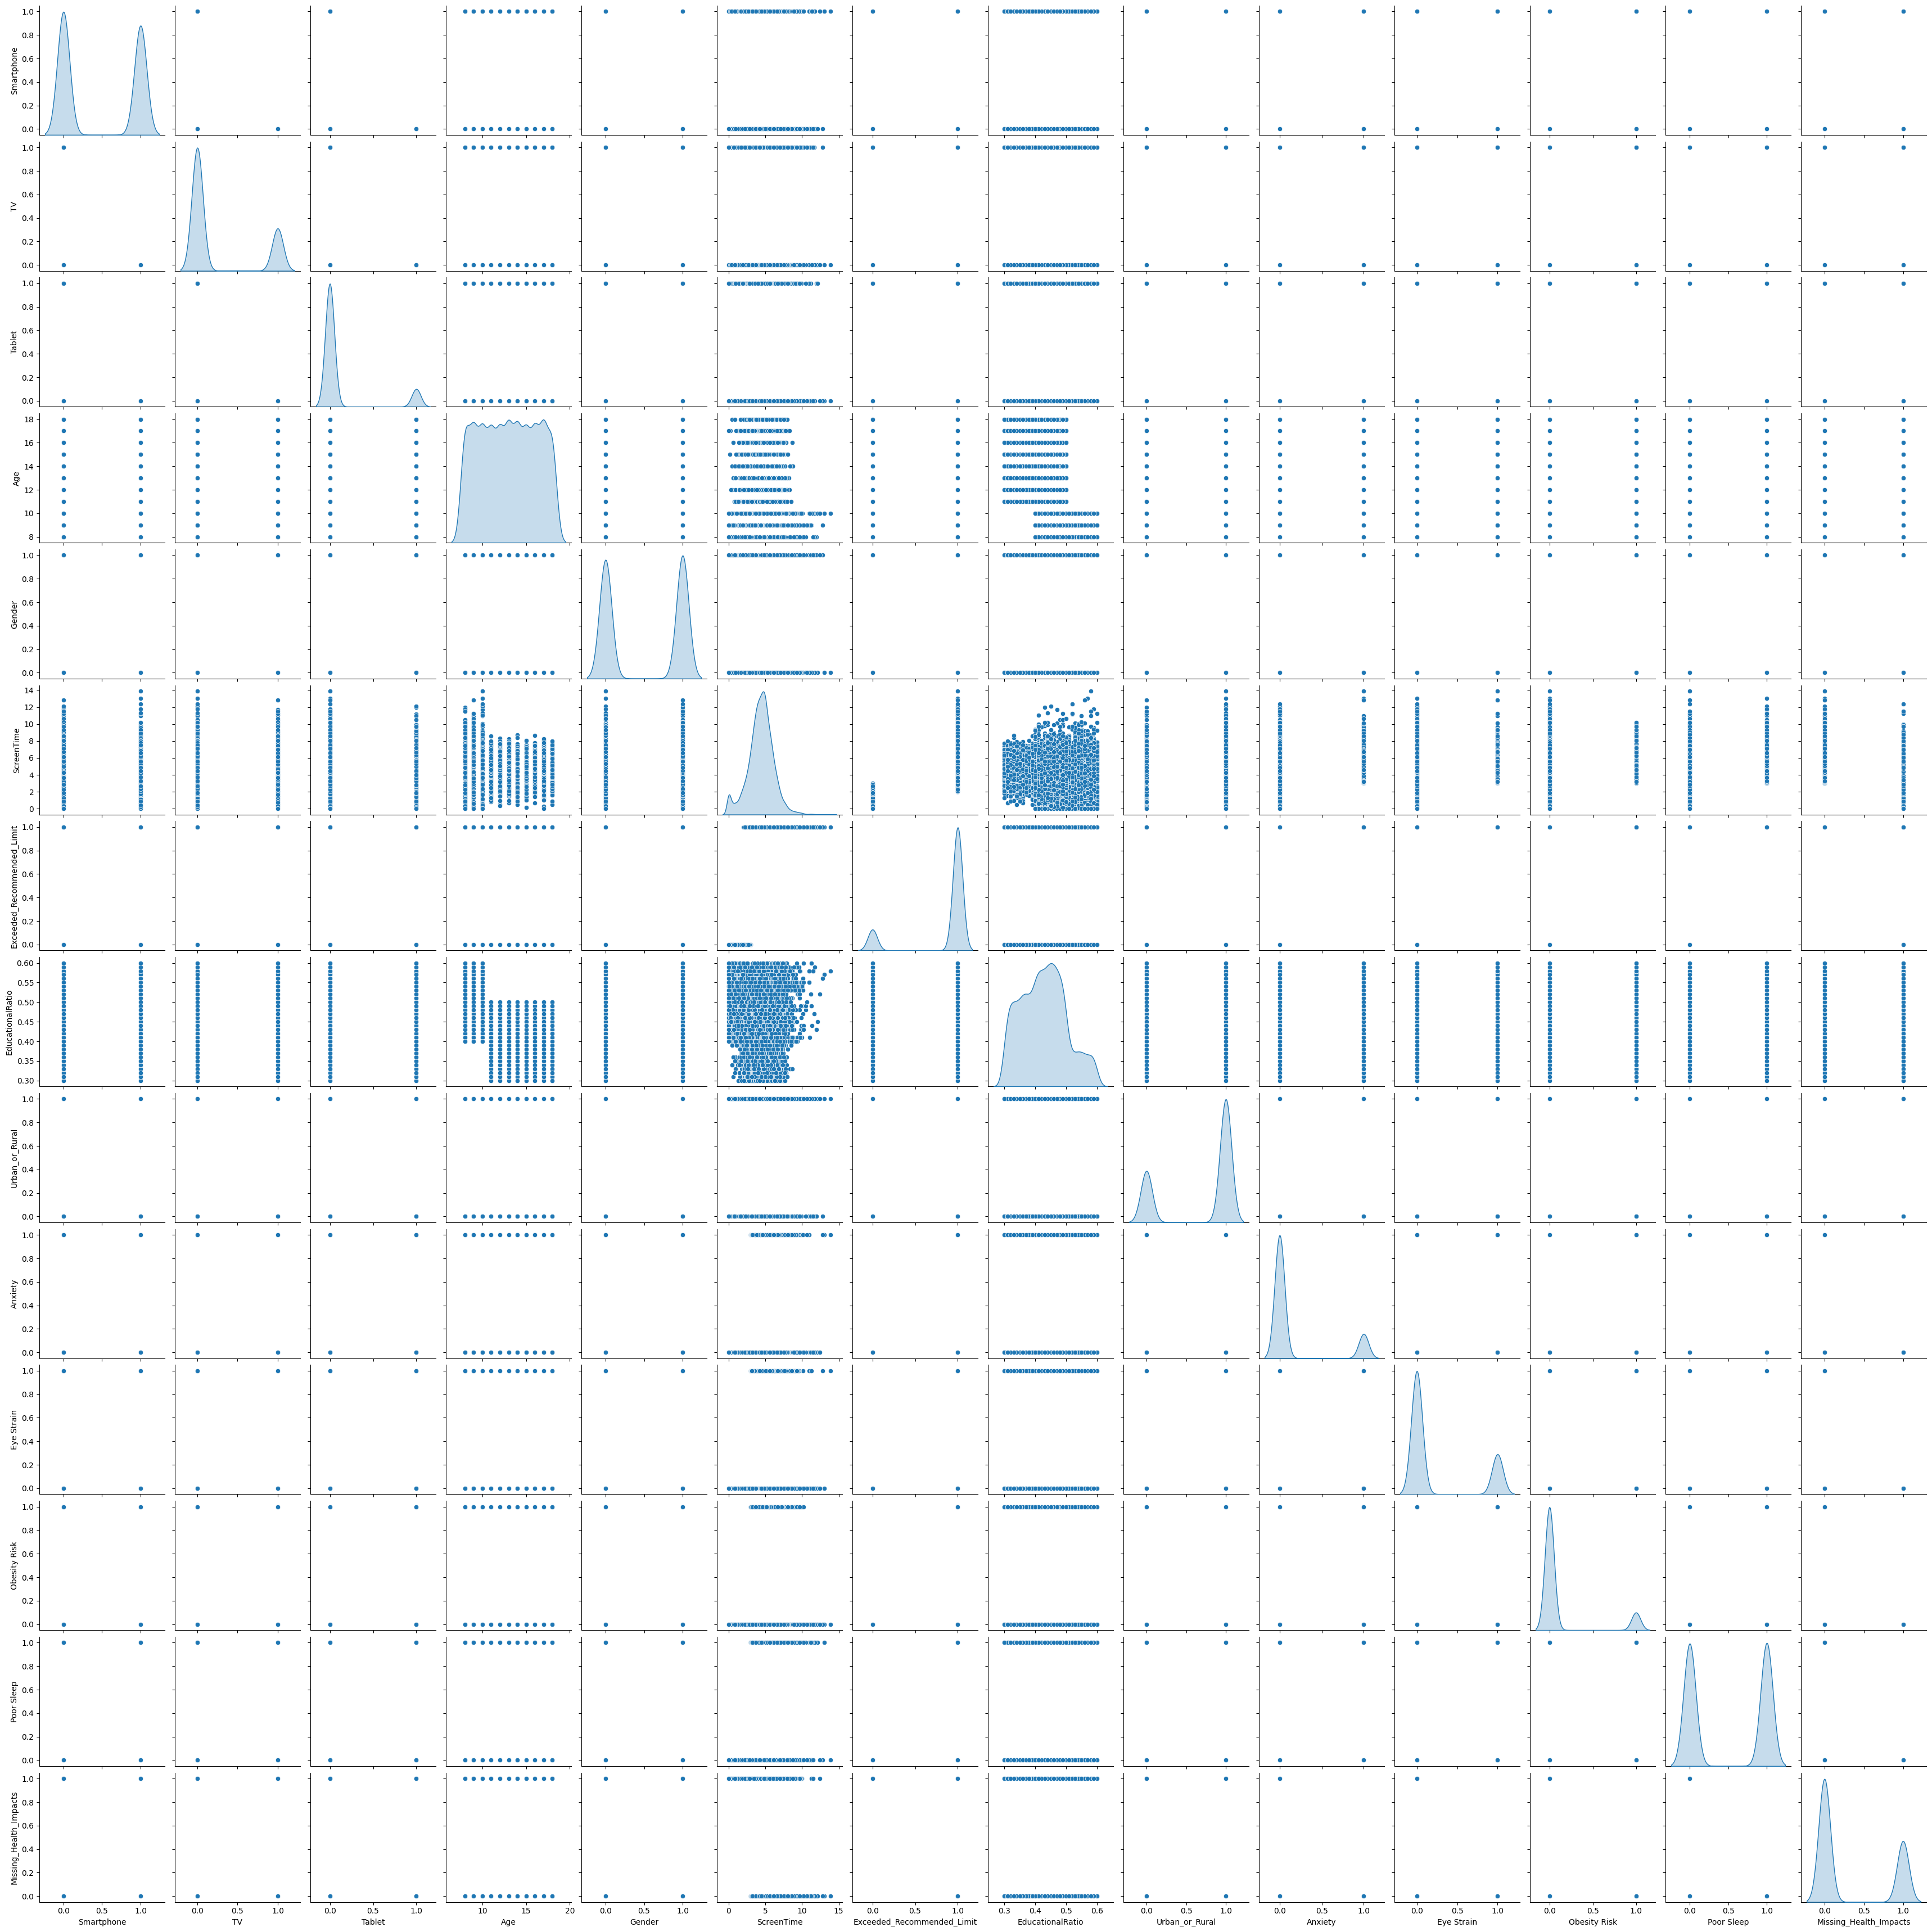

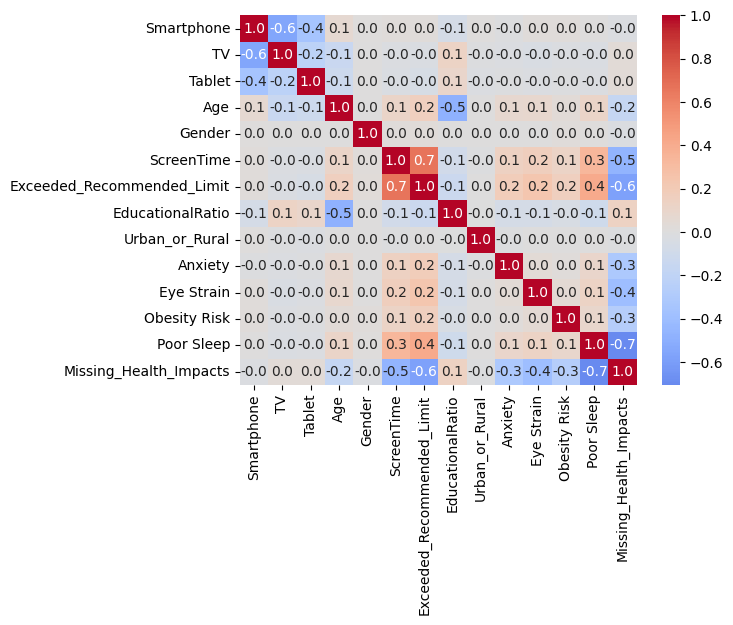

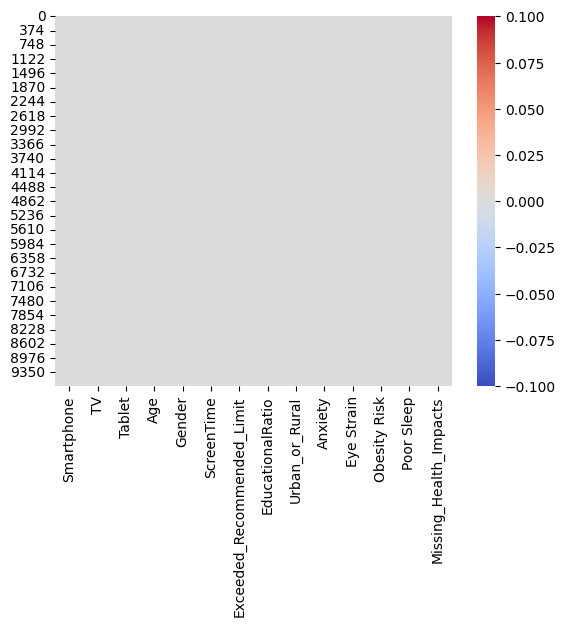

In [29]:
sns.pairplot(df, diag_kind="kde")
plt.show()
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap="coolwarm", center=0)
plt.show()
sns.heatmap(df.isna(), cmap="coolwarm")
plt.show()

In [35]:
# Prepare data for modelling
from sklearn.model_selection import train_test_split
X = sm.add_constant(df.drop("ScreenTime", axis=1))
y = df["ScreenTime"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerics = ["Age", "EducationalRatio"]    
X_train[numerics] = scaler.fit_transform(X_train[numerics])
X_test[numerics] = scaler.transform(X_test[numerics])

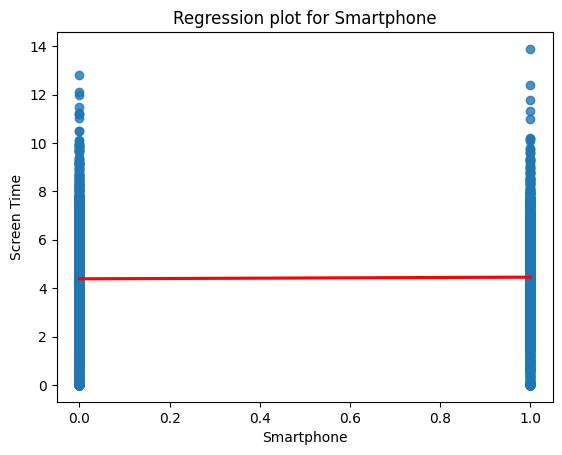

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


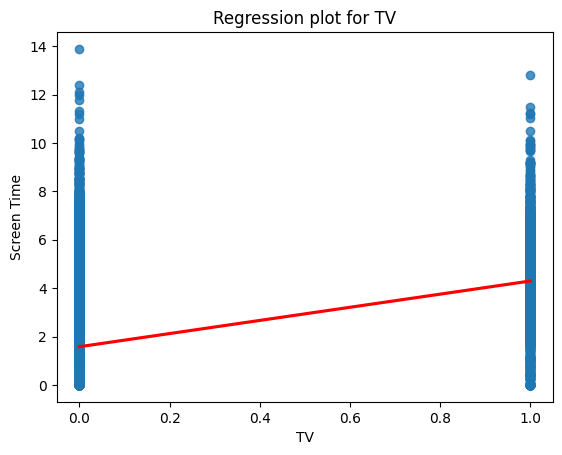

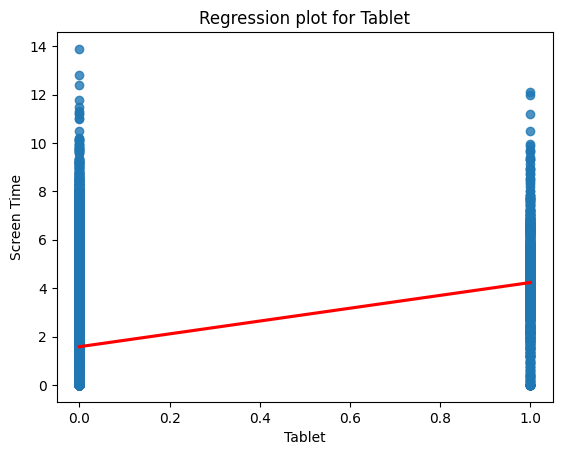

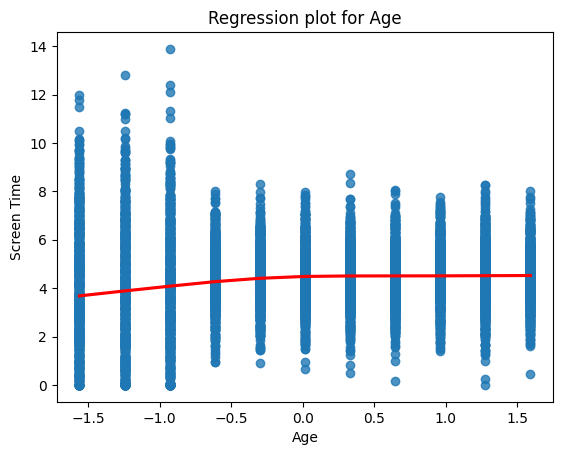

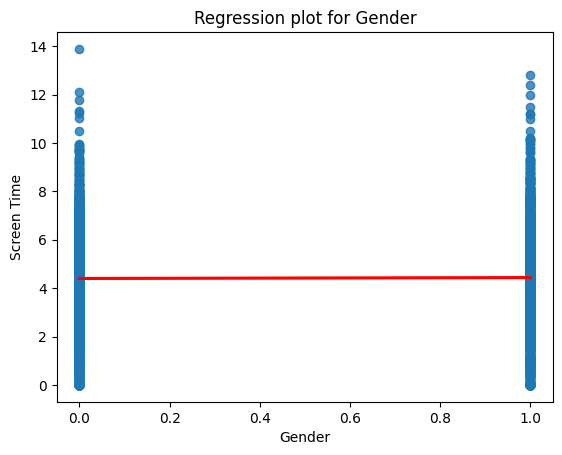

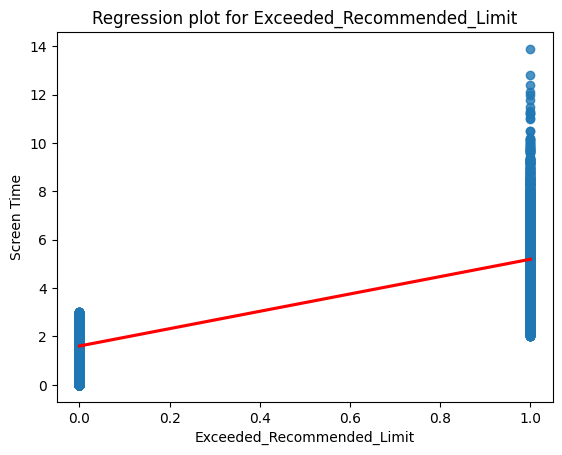

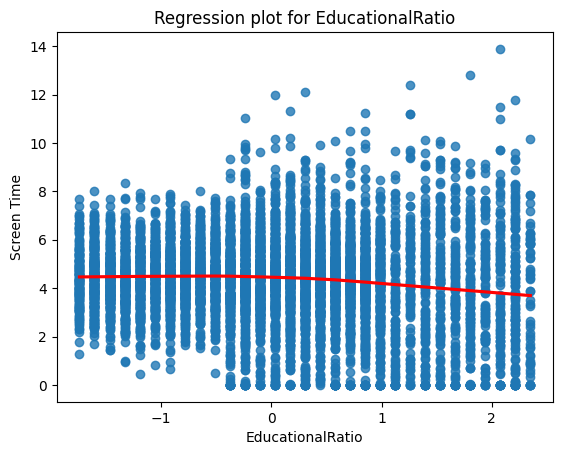

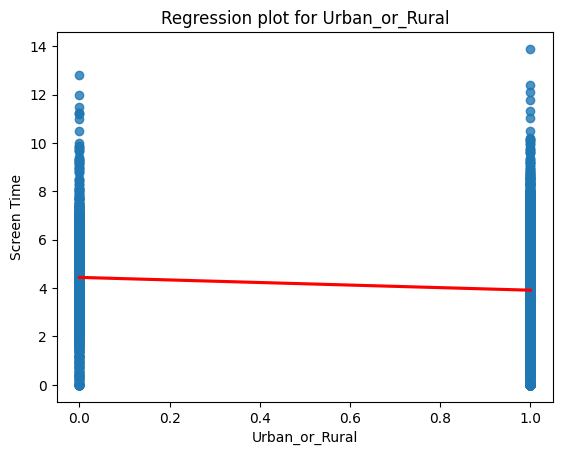

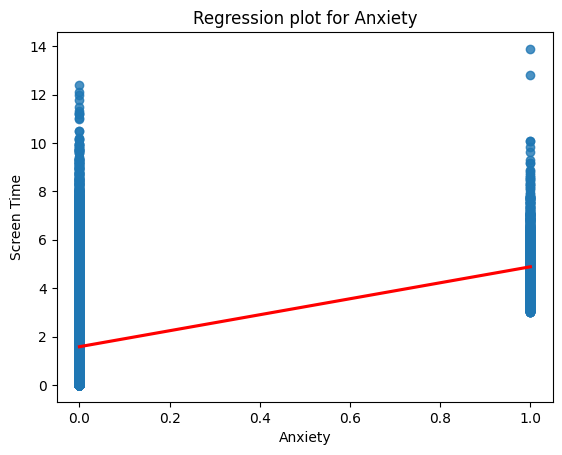

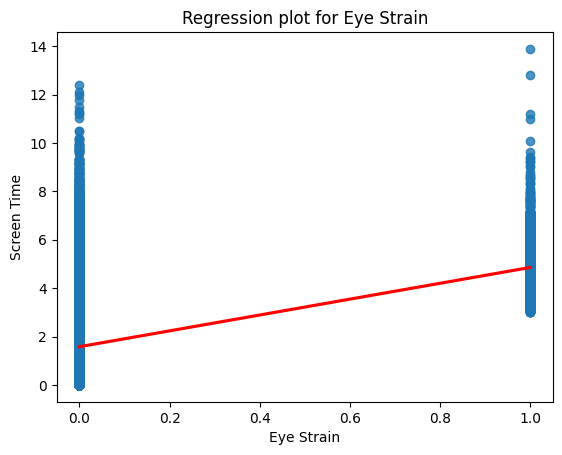

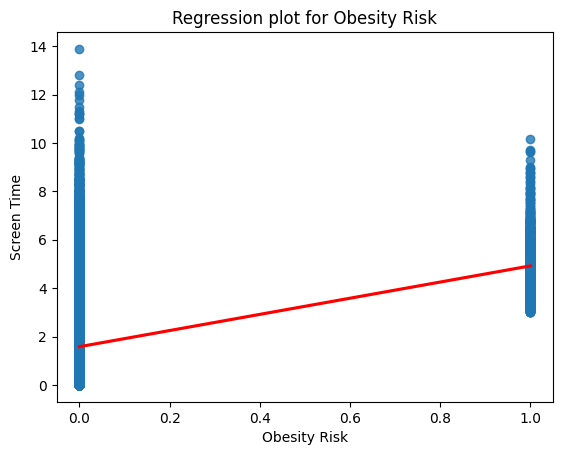

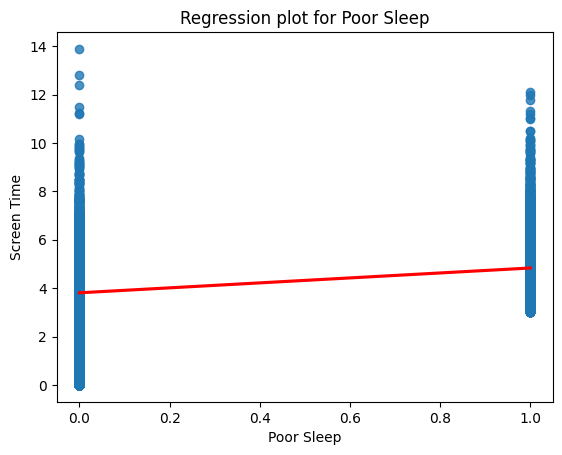

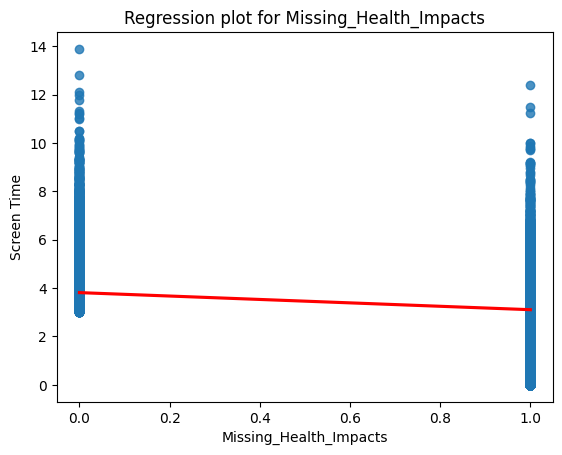

In [33]:
for feature in X_train.columns:
    sns.regplot(x=X_train[feature], y=y_train, lowess=True, line_kws={"color": "red"})
    plt.title(f"Regression plot for {feature}")
    plt.xlabel(feature)
    plt.ylabel("Screen Time")
    plt.show()

In [41]:
# Fit OLS regression model
import statsmodels.api as sm
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

# Calculate performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
OLS_pred = OLS.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, OLS_pred):.2f}, MSE: {mean_squared_error(y_test, OLS_pred):.2f}, R^2: {r2_score(y_test, OLS_pred):.2f}")

                            OLS Regression Results                            
Dep. Variable:             ScreenTime   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     490.3
Date:                Sat, 26 Jul 2025   Prob (F-statistic):               0.00
Time:                        19:15:43   Log-Likelihood:                -12919.
No. Observations:                7769   AIC:                         2.587e+04
Df Residuals:                    7755   BIC:                         2.596e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

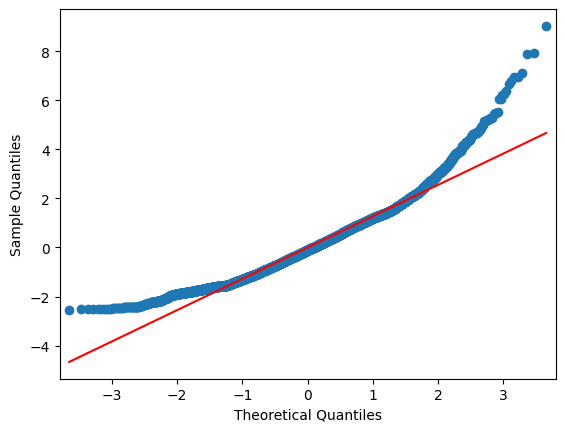

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


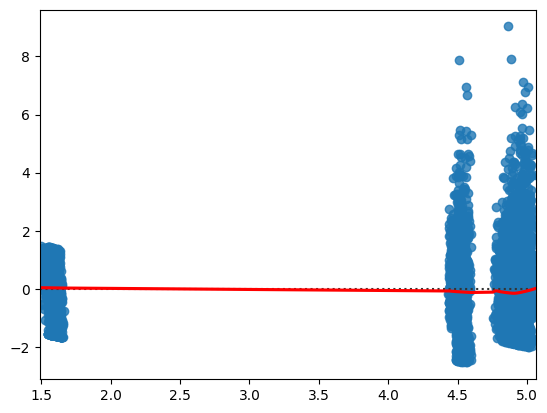

In [39]:
# Check for normality of residuals
qq = sm.qqplot(OLS.resid, line='s')
plt.show()
# Scale - location plot
plot = sns.residplot(x=OLS.fittedvalues, y=OLS.resid, lowess=True, line_kws={"color": "red"})
plt.show()

In [43]:
# Fit tweedie GLM
Tweedie = sm.GLM(y_train, X_train, family=sm.families.Tweedie(var_power=1.5, link=sm.families.links.Log())).fit()
print(Tweedie.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             ScreenTime   No. Observations:                 7769
Model:                            GLM   Df Residuals:                     7755
Model Family:                 Tweedie   Df Model:                           13
Link Function:                    Log   Scale:                         0.21931
Method:                          IRLS   Log-Likelihood:                -14601.
Date:                Sat, 26 Jul 2025   Deviance:                       2330.4
Time:                        19:16:49   Pearson chi2:                 1.70e+03
No. Iterations:                    13   Pseudo R-squ. (CS):             0.6248
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

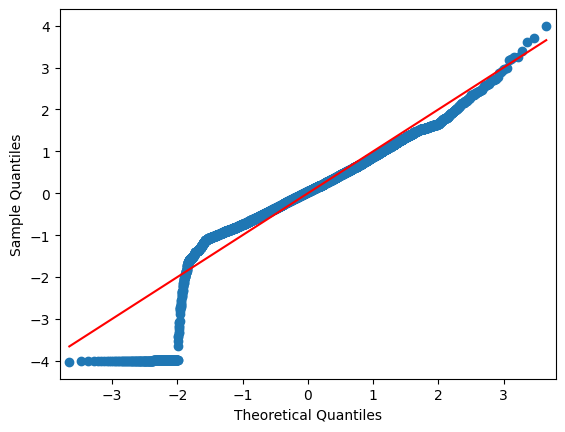

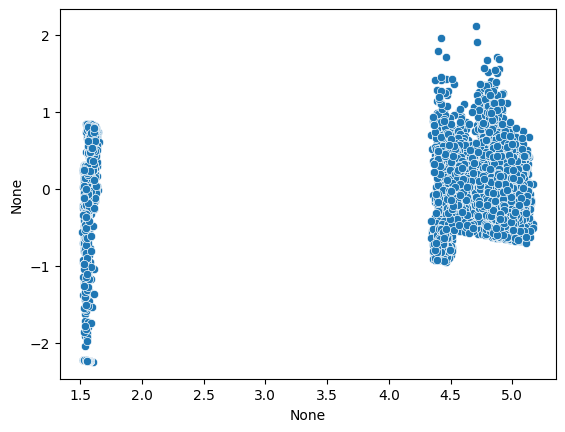

In [48]:
qq = sm.qqplot(stats.zscore(Tweedie.resid_deviance), line = "s")
plt.show()
# Plot predictions against fitted values
sns.scatterplot(x=Tweedie.fittedvalues, y=Tweedie.resid_deviance)
plt.show()

<Axes: >

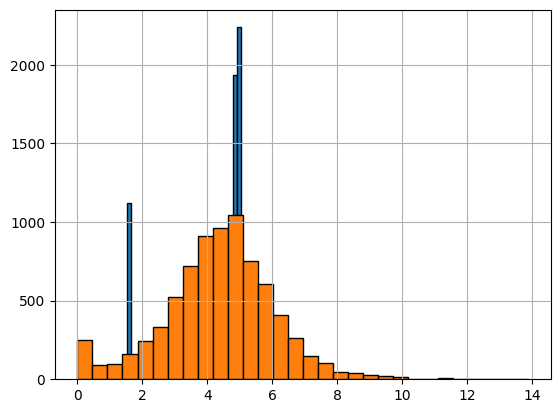

In [52]:
Tweedie.fittedvalues.hist(bins=30, edgecolor='black')
y_train.hist(bins=30, edgecolor='black')

In [53]:
# Fit LightGBM model
import lightgbm as lgb
lgb_train = lgb.Dataset(X_train, label=y_train)
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}
lgb_model = lgb.train(params, lgb_train, num_boost_round=100)
lgb_pred = lgb_model.predict(X_test)
print(f"LGBM MAE: {mean_absolute_error(y_test, lgb_pred):.2f}, MSE: {mean_squared_error(y_test, lgb_pred):.2f}, R^2: {r2_score(y_test, lgb_pred):.2f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 66
[LightGBM] [Info] Number of data points in the train set: 7769, number of used features: 13
[LightGBM] [Info] Start training from score 4.361452
LGBM MAE: 0.92, MSE: 1.42, R^2: 0.51


In [64]:
df.query("Age == 10 and Anxiety == 1 & (ScreenTime > 4 | ScreenTime <1)")

,Smartphone,TV,Tablet,Age,Gender,ScreenTime,Exceeded_Recommended_Limit,EducationalRatio,Urban_or_Rural,Anxiety,Eye Strain,Obesity Risk,Poor Sleep,Missing_Health_Impacts
364,0,1,0,10,0,6.09,1,0.47,0,1,1,1,0,0
381,0,1,0,10,1,5.88,1,0.41,1,1,0,0,0,0
541,1,0,0,10,0,5.24,1,0.57,1,1,0,0,0,0
549,0,0,1,10,1,4.22,1,0.54,1,1,0,0,1,0
670,0,1,0,10,1,6.10,1,0.51,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8890,1,0,0,10,0,7.67,1,0.46,0,1,0,0,1,0
8997,0,0,1,10,1,6.50,1,0.45,1,1,1,0,0,0
9301,1,0,0,10,1,6.16,1,0.56,1,1,0,0,1,0
9523,1,0,0,10,0,6.87,1,0.59,1,1,0,0,1,0
